In [61]:
import numpy as np
import matplotlib.pyplot as plt
import time

from src.simulation import Simulation
from src.config import Config
from src.builders import build_problem
from src.noise import add_noise_snr
from src.layers import create_layers, create_layers_from_interfaces, update_from_arrays
from src.misfit import l2_misfit
from src.plot.plot_tools import set_plot_style, plot_seismogram
set_plot_style()

config = Config(n_receivers=8, x_min=0., x_max=2000.,
                   z_rec=50., z_src=20., x_src=50., nq_prop=512, f0=3.5, nq_evan=256, kx_max_factor=6.,
                   total_time=2.0, delay=0.2, epsilon=1.25, free_surface=True, nfft_pad_factor=1)
param, acq = build_problem(config)
dxr = acq.xr[1] - acq.xr[0]
dt = param.dt
seed = 42

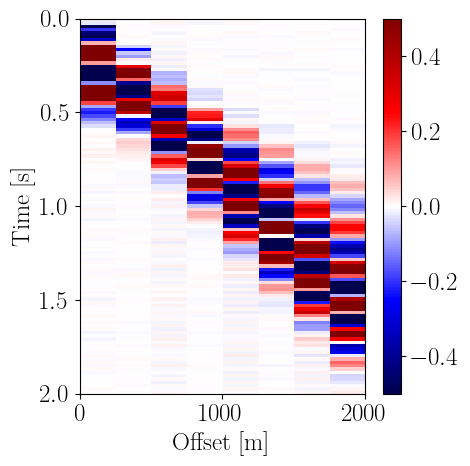

In [62]:
vps = np.array([1500.0, 2700.0, 3200.0]) # 3 velocities
vp_ref = np.array([vps[1], vps[2]])
z_int = np.array([0.0, 100., 250., 400.])
#h_ref = np.array([100.0, 150., 50.])
# h = 100. 250. 250. # len(h) = len(z_int) - 1  # 3 widths, get gradient for 2 widths
rhos = np.array([2000.0, 2000.0, 2000.0])
#layers = create_layers(h_ref, vps, rhos)
layers = create_layers_from_interfaces(z_int, vps, rhos)

sim = Simulation(config)
d_obs = sim.forward(layers)
d_obs_noise, std_noise = add_noise_snr(d_obs, snr_db=40, seed=seed)
plot_seismogram(d_obs_noise.T, sim.acq.xr, sim.param.time, vmin=-0.5, vmax=0.5, ncolors=256, figsize=(5,5))

In [63]:
vp_min, vp_max, npts = 800, 3500, 60 # 800, 4000, 150

x_vals = np.linspace(vp_min, vp_max, npts)
y_vals = np.linspace(vp_min, vp_max, npts)
xgrid, ygrid = np.meshgrid(x_vals, y_vals, indexing='ij')
COST = np.empty_like(xgrid)

start_time = time.time()
for i in range(npts):
    for j in range(npts):
        point = np.array([xgrid[i, j], ygrid[i, j]])
        VP = np.array([point[0], point[1], vps[2]])
        layers = update_from_arrays(layers, vps=VP)
        d_cal = sim.forward(layers)
        COST[i,j] = l2_misfit(d_cal, d_obs_noise, std_noise=float(std_noise))

elapsed_time = time.time() - start_time
print(f"generated misfit map in {elapsed_time:.3f} seconds.")
print(f"time per forward is {elapsed_time/(npts*npts):.3f} seconds.")

generated misfit map in 165.196 seconds.
time per forward is 0.046 seconds.


In [64]:
vp_ming, vp_maxg, nptsg = 900, 3400, 13

x_valsg = np.linspace(vp_ming, vp_maxg, nptsg)
y_valsg = np.linspace(vp_ming, vp_maxg, nptsg)
xgridg, ygridg = np.meshgrid(x_valsg, y_valsg, indexing='ij')
GRADV1 = np.empty_like(xgridg)
GRADV2 = np.empty_like(xgridg)

start_time = time.time()
for i in range(nptsg):
    for j in range(nptsg):
        point = np.array([xgridg[i, j], ygridg[i, j]])
        VP = np.array([point[0], point[1], vps[2]])
        #VP = np.array([vps[0], point[0], point[1]])
        layers = update_from_arrays(layers, vps=VP)
        d_cal = sim.forward(layers)
        gradvp, _, _ = sim.gradient(residual= d_cal[0] - d_obs_noise[0], layers=layers)
        GRADV1[i,j] = gradvp[1]
        GRADV2[i,j] = gradvp[2]

elapsed_time = time.time() - start_time
print(f"generated misfit map in {elapsed_time:.3f} seconds.")
print(f"time per forward is {elapsed_time/(npts*npts):.3f} seconds.")

generated misfit map in 23.151 seconds.
time per forward is 0.006 seconds.


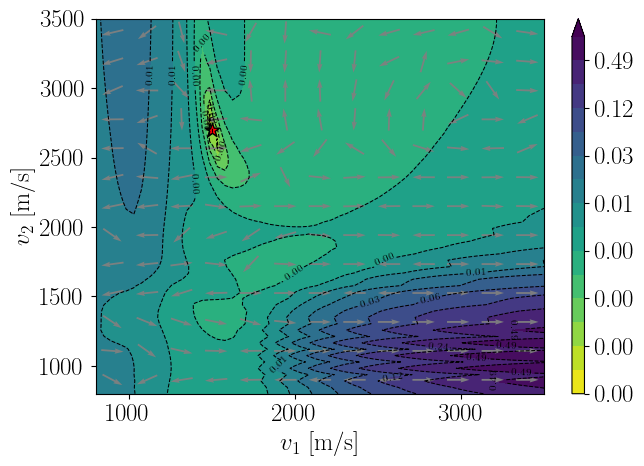

In [65]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from matplotlib.ticker import FixedLocator, FormatStrFormatter

X = xgrid
Y = ygrid
X2 = xgridg
Y2 = ygridg
# ---------------------------------------------------------
# Normalize gradient arrows for visualization
# ---------------------------------------------------------
Gx = -GRADV1
Gy = -GRADV2
norm = np.sqrt(Gx**2 + Gy**2)
# Avoid division by zero
norm[norm == 0] = 1.0
Gx_n = Gx / norm
Gy_n = Gy / norm

fig, ax = plt.subplots(figsize=(7, 5))
min_C = np.min(COST / np.max(COST))
# Cost contours
contour_lines = ax.contour(
    X,
    Y,
    COST / np.max(COST),
    levels=np.geomspace(min_C, 1., 16),
    colors="black",
    linewidths=0.75,
    linestyles="dashed",
)
ax.clabel(contour_lines, inline=True, fontsize=7, fmt="%.2f")
cf = ax.contourf(
    X,
    Y,
    COST / np.max(COST),
    levels=np.geomspace(min_C, 1., 16),
    norm=LogNorm(vmin=min_C, vmax=1.),
    cmap="viridis_r",
    extend="max",
)
ax.quiver(
    X2,
    Y2,
    Gx_n,
    Gy_n,
    color="gray",
    alpha=0.95,
    pivot="mid",
    angles="uv",
    scale=20,
    width=0.004,
)
ax.scatter(
    vps[0],
    vps[1],
    s=115,
    c="red",
    marker="*",
    alpha=1,
    edgecolors="k",
)
ax.set_xlabel(r"$v_1$ [m/s]")
ax.set_ylabel(r"$v_2$ [m/s]")
ax.set_xlim([vp_min, vp_max])
ax.set_ylim([vp_min, vp_max])
cbar = fig.colorbar(cf, aspect=30)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.tight_layout()
plt.show()

In [9]:
vp_min, vp_max, npts = 1000, 6000, 60 # 800, 4000, 150
h_min, h_max = 10., 600.

x_vals = np.linspace(vp_min, vp_max, npts)
y_vals = np.linspace(h_min, h_max, npts)
xgrid, ygrid = np.meshgrid(x_vals, y_vals, indexing='ij')
COST = np.empty_like(xgrid)

start_time = time.time()
for i in range(npts):
    for j in range(npts):
        point = np.array([xgrid[i, j], ygrid[i, j]])
        VP = np.array([1500.0, 1800., point[0]])
        H = np.array([100., point[1], 50.])
        layers = create_layers(H, VP, rhos)
        d_cal = sim.forward(layers)
        COST[i,j] = l2_misfit(d_cal, d_obs, std_noise=float(1.))

elapsed_time = time.time() - start_time
print(f"generated misfit map in {elapsed_time:.3f} seconds.")
print(f"time per forward is {elapsed_time/(npts*npts):.3f} seconds.")

generated misfit map in 275.310 seconds.
time per forward is 0.076 seconds.


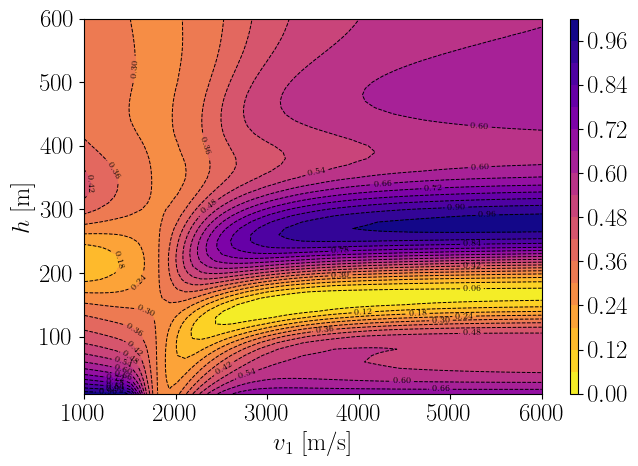

In [10]:
X = xgrid
Y = ygrid
fig, ax = plt.subplots(figsize=(7, 5))
# Cost contours
contour_lines = ax.contour(
    X,
    Y,
    COST / np.max(COST),
    levels=16,
    colors="black",
    linewidths=0.7,
    linestyles="dashed",
)
ax.clabel(contour_lines, inline=True, fontsize=6, fmt="%.2f")
cf = ax.contourf(
    X,
    Y,
    COST / np.max(COST),
    levels=16,
    cmap="plasma_r",
    vmax=1.
)
ax.set_xlabel(r"$v_1$ [m/s]")
ax.set_ylabel(r"$h$ [m]")
ax.set_xlim([vp_min, vp_max])
ax.set_ylim([h_min, h_max])
fig.colorbar(cf, aspect=50)
plt.tight_layout()
plt.show()

In [11]:
vp_min, vp_max, npts = 1000, 6000, 60

x_vals = np.linspace(vp_min, vp_max, npts)
y_vals = np.linspace(vp_min, vp_max, npts)
xgrid, ygrid = np.meshgrid(x_vals, y_vals, indexing='ij')
COST = np.empty_like(xgrid)

start_time = time.time()
for i in range(npts):
    for j in range(npts):
        point = np.array([xgrid[i, j], ygrid[i, j]])
        VP = np.array([1500.0, point[0], point[1]])
        H = np.array([100., 150., 50.])
        layers = create_layers(H, VP, rhos)
        d_cal = sim.forward(layers)
        COST[i,j] = l2_misfit(d_cal, d_obs, std_noise=float(1.))

elapsed_time = time.time() - start_time
print(f"generated misfit map in {elapsed_time:.3f} seconds.")
print(f"time per forward is {elapsed_time/(npts*npts):.3f} seconds.")

generated misfit map in 269.999 seconds.
time per forward is 0.075 seconds.


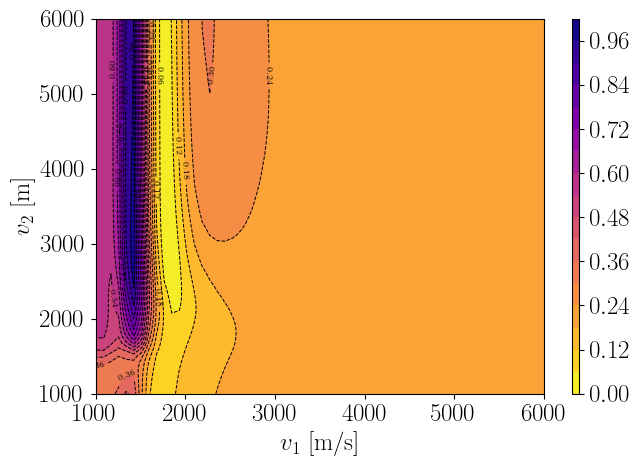

In [12]:
X = xgrid
Y = ygrid
fig, ax = plt.subplots(figsize=(7, 5))
# Cost contours
contour_lines = ax.contour(
    X,
    Y,
    COST / np.max(COST),
    levels=16,
    colors="black",
    linewidths=0.7,
    linestyles="dashed",
)
ax.clabel(contour_lines, inline=True, fontsize=6, fmt="%.2f")
cf = ax.contourf(
    X,
    Y,
    COST / np.max(COST),
    levels=16,
    cmap="plasma_r",
    vmax=1.
)
ax.set_xlabel(r"$v_1$ [m/s]")
ax.set_ylabel(r"$v_2$ [m]")
ax.set_xlim([vp_min, vp_max])
ax.set_ylim([vp_min, vp_max])
fig.colorbar(cf, aspect=50)
plt.tight_layout()
plt.show()

In [13]:
vp_min, vp_max, npts = 1000, 6000, 60

x_vals = np.linspace(vp_min, vp_max, npts)
y_vals = np.linspace(vp_min, vp_max, npts)
xgrid, ygrid = np.meshgrid(x_vals, y_vals, indexing='ij')
COST = np.empty_like(xgrid)

start_time = time.time()
for i in range(npts):
    for j in range(npts):
        point = np.array([xgrid[i, j], ygrid[i, j]])
        VP = np.array([1500.0, point[0], point[1]])
        H = np.array([100., 259.3, 50.])
        layers = create_layers(H, VP, rhos)
        d_cal = sim.forward(layers)
        COST[i,j] = l2_misfit(d_cal, d_obs, std_noise=float(1.))

elapsed_time = time.time() - start_time
print(f"generated misfit map in {elapsed_time:.3f} seconds.")
print(f"time per forward is {elapsed_time/(npts*npts):.3f} seconds.")

generated misfit map in 256.587 seconds.
time per forward is 0.071 seconds.


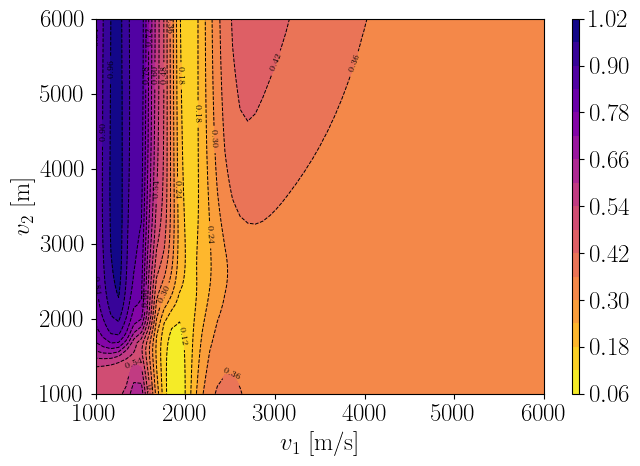

In [14]:
X = xgrid
Y = ygrid
fig, ax = plt.subplots(figsize=(7, 5))
# Cost contours
contour_lines = ax.contour(
    X,
    Y,
    COST / np.max(COST),
    levels=16,
    colors="black",
    linewidths=0.7,
    linestyles="dashed",
)
ax.clabel(contour_lines, inline=True, fontsize=6, fmt="%.2f")
cf = ax.contourf(
    X,
    Y,
    COST / np.max(COST),
    levels=16,
    cmap="plasma_r",
    vmax=1.
)
ax.set_xlabel(r"$v_1$ [m/s]")
ax.set_ylabel(r"$v_2$ [m]")
ax.set_xlim([vp_min, vp_max])
ax.set_ylim([vp_min, vp_max])
fig.colorbar(cf, aspect=50)
plt.tight_layout()
plt.show()